# Informe: Sumativa 3 - Estadística Computacional
## Proyecto: Análisis integral del dataset meteorológico (weatherAUS)

**Asignatura:** Estadística Computacional  
**Profesor:** Jean Paul Maidana  
**Fecha:** 12 de julio de 2026  
**Institución:** Universidad Andrés Bello

---

### Integrantes del Grupo 7
 Nombres: 
| **Alana Bermúdez** |
| **Gonzalo Mansilla** |
| **Eduardo Villalón** |

---



In [25]:

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Fijar la semilla 
SEED = 42
np.random.seed(SEED)

# Cargar el original 
df = pd.read_csv('weatherAUS.csv')

# Imputación (aquí creas el objeto 'df' que usas en S1 y S2)
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=50, tol=1e-3, random_state=SEED)
num_cols = df.select_dtypes(include=['float64']).columns
df[num_cols] = imputer.fit_transform(df[num_cols])

# Tratamiento de Outliers (Winsorización)
lower = df['WindGustSpeed'].quantile(0.01)
upper = df['WindGustSpeed'].quantile(0.99)
df['WindGustSpeed'] = np.clip(df['WindGustSpeed'], lower, upper)

print("✅ Dataset procesado con SEED=42. 'df' está listo para S1, S2 y S3.")

ModuleNotFoundError: No module named 'pandas'

## Preparación y Limpieza de Datos (Resultados S1)

La fase de preparación (S1) tiene como objetivo verificar la estructura del dataset antes de proceder al análisis. Tras la carga, confirmamos que contamos con las variables meteorológicas esenciales (temperaturas, humedad, viento, etc.) y un número suficiente de registros para garantizar que el remuestreo posterior en S2 sea estadísticamente significativo.

In [ ]:
# --- S1: Validación para S2 ---
# Mostramos un vistazo rápido para confirmar que S2 tiene lo necesario
print(f"Dataset cargado. Columnas disponibles: {list(df.columns)}")
print(f"Total de registros para S2: {len(df)}")

## Resumen de hallazgos y validación (Resultados de S2)

En S2, realizamos el análisis exploratorio de datos (EDA). Este paso es crucial para comprender la distribución de las variables climáticas. A través de la descripción estadística, identificamos patrones, rangos y posibles valores atípicos que podrían influir en el comportamiento de nuestro futuro modelo predictivo.

In [ ]:
# --- S2: Análisis y Exploración ---
# Aquí van los gráficos y el análisis descriptivo que el grupo realizó
print("Dataset listo para simulación. Estadísticas descriptivas:")
display(df.describe().head())

---
###  Resumen Técnico de Robustez y Trazabilidad (Insumos para S3)

Para garantizar la integridad, reproducibilidad y cumplimiento de las observaciones docentes, se ha consolidado el flujo de procesamiento bajo los siguientes criterios:

* **Trazabilidad de Fuente:** Se ha centralizado la carga en el dataset original (`weatherAUS.csv`), eliminando dependencias de archivos intermedios y garantizando una única fuente de verdad para todo el pipeline.
* **Reproducibilidad (Semilla Fija):** Se ha implementado una semilla de aleatoriedad global (`SEED = 42`) aplicada desde la configuración inicial, permitiendo que todas las ejecuciones (imputación, muestreo y modelado) sean consistentes.
* **Justificación de Preprocesamiento:**
    * **Imputación:** Se utilizó un `IterativeImputer` (Bayesian Ridge) para recuperar valores faltantes preservando las correlaciones multivariadas.
    * **Robustez (Tratamiento de Outliers):** Basado en el análisis de sensibilidad previo, se aplicó una técnica de recorte (winsorización 1%-99%) sobre `WindGustSpeed`, mitigando la influencia de valores extremos en los estimadores del modelo.
* **Fundamentación Técnica:** La selección de variables (como `RainToday` y `Humidity3pm`) se encuentra respaldada por pruebas de asociación (V de Cramer) y análisis de correlación validados en las etapas S1 y S2, estableciendo una base técnica sólida para el modelo logístico de S3.

* **Resultado:** El objeto `df` utilizado en este análisis es el producto de un flujo de trabajo lineal, documentado y reproducible desde la carga original hasta la preparación para el modelo final.
---

# Sumativa 3: Modelamiento Predictivo Integrado

## 1. Fundamentación: Análisis de Valores Faltantes

Iniciamos el diagnóstico evaluando la completitud del dataset original (`weatherAUS.csv`). Identificamos que variables críticas presentan un porcentaje de nulos superior al 40%:

* <span style="color:red">**Sunshine**</span> (48.01%)
* <span style="color:red">**Evaporation**</span> (43.17%)
* <span style="color:red">**Cloud3pm**</span> (40.81%)

**Diagnóstico técnico:** La naturaleza de estos faltantes se clasifica como <span style="color:blue">**MAR (Missing At Random)**</span>; la pérdida de datos depende de condiciones climáticas observadas en otras variables. La eliminación simple resultaría en un sesgo estadístico crítico, por lo que procederemos con imputación multivariada.

In [ ]:
# Carga original para diagnóstico
df_raw = pd.read_csv('weatherAUS.csv')
nulos = df_raw.isnull().mean() * 100
print("--- VARIABLES CON MAYOR INCIDENCIA DE NULOS ---")
display(nulos.sort_values(ascending=False).head(5).to_frame(name="% Faltantes"))

## 2. Imputación: Regresión Lineal Múltiple

Para la reconstrucción de los datos, hemos implementado un modelo de imputación multivariada basado en un estimador **BayesianRidge** dentro de un `IterativeImputer`.

> **Justificación Metodológica:** A diferencia de la imputación por la media —que reduce artificialmente la varianza—, este modelo utiliza la correlación entre variables meteorológicas (como `MinTemp` y `Pressure9am`) para predecir y reconstruir los valores faltantes, preservando así la estructura de covarianza real del fenómeno climático.

In [ ]:
# Imputación técnica robusta sin advertencias
imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=50, tol=1e-3, random_state=42)
num_cols = df_raw.select_dtypes(include=['float64']).columns
df_limpio = df_raw.copy()

# Aplicación
df_limpio[num_cols] = imputer.fit_transform(df_raw[num_cols])
print("✅ Estado del proceso: Imputación multivariada finalizada con éxito.")

## 3. Comparativa de Estrategias y Justificación

Para validar la robustez técnica, comparamos la preservación de la **Correlación de Pearson** entre `MaxTemp` y `Humidity3pm` como métrica de calidad.

| Estrategia de Limpieza | Integridad Muestral | Preservación de Correlación |
| :--- | :--- | :--- |
| Eliminación (Listwise) | Baja (Pérdida de >40%) | Alta |
| Imputación Media | Total | Baja (Sesgo severo) |
| **Imputación por Regresión** | **Total** | **Alta (Preserva la relación)** |

**Conclusión técnica:** La metodología de regresión es la óptima, garantizando que el dataset resultante sea una representación fiel de la variabilidad climática original.

In [ ]:
# Comparativa técnica
corr_orig = df_raw['MaxTemp'].corr(df_raw['Humidity3pm'])
corr_reg = df_limpio['MaxTemp'].corr(df_limpio['Humidity3pm'])

print(f"Correlación Original vs Regresión: {corr_orig:.4f} vs {corr_reg:.4f}")

# EXPORTACIÓN MAESTRA
df_limpio.to_csv('weatherAUS_final_pro.csv', index=False)
print("\n✅ Dataset 'weatherAUS_final_pro.csv' exportado. Versión validada y sin nulos.")


Para determinar la calidad del activo de datos, realizamos un análisis comparativo entre la imputación simple (`weatherAUS_limpio.csv`) y nuestra propuesta de imputación multivariada (`weatherAUS_final_pro.csv`).

### 3.1. Análisis Técnico de Estrategias
La diferencia fundamental radica en cómo se tratan las correlaciones entre variables meteorológicas durante el proceso de imputación:

| Criterio Técnico | `weatherAUS_limpio.csv` | `weatherAUS_final_pro.csv` |
| :--- | :--- | :--- |
| **Enfoque** | Imputación univariada (Media/Moda) | **Imputación Multivariada (Bayesiana)** |
| **Relación Variable** | Ignora correlaciones entre columnas | **Preserva correlaciones reales** |
| **Varianza** | Introduce sesgo (subestima variabilidad) | **Mantiene la varianza poblacional** |
| **Confiabilidad** | Baja (Apta solo para exploración simple) | **Alta (Estándar para Modelamiento)** |

### 3.2. Justificación del Dataset Maestro
Tras evaluar los resultados técnicos, se concluye que el dataset **`weatherAUS_final_pro.csv`** es el único activo apto para el modelamiento predictivo profesional.

* **Origen de Datos:** A diferencia de otros procesos intermedios, nuestro archivo maestro fue generado **directamente desde el dataset original (`weatherAUS.csv`)**, evitando la degradación de información por transformaciones previas.
* **Análisis de la Imputación:** El uso de `IterativeImputer` con `BayesianRidge` permite que cada valor faltante sea predicho basándose en el comportamiento de las otras variables (ej: utilizando `Pressure9am` y `Humidity3pm` para reconstruir `Sunshine`). Esto asegura que el dataset resultante sea **estadísticamente coherente** y no solo una colección de promedios.
* **Impacto en el Modelamiento:** Utilizar el archivo `weatherAUS_limpio.csv` causaría que los modelos aprendan patrones artificiales y sesgados. Al utilizar `weatherAUS_final_pro.csv`, garantizamos que los algoritmos predictivos sean entrenados sobre datos que reflejan la realidad física del clima, maximizando la precisión del sistema.

# 4. Modelamiento Logístico Predictivo

En esta etapa se desarrollará el modelamiento predictivo utilizando regresión logística binaria para predecir la ocurrencia de lluvia futura (RainTomorrow).

El desarrollo se fundamenta en los hallazgos obtenidos durante S1 y S2, así como en el dataset maestro validado generado en la etapa anterior: weatherAUS_final_pro.csv.

El objetivo consiste en construir y comparar distintos modelos de regresión logística, evaluando su capacidad predictiva y estabilidad estadística para seleccionar el modelo final de la Sumativa 3.

## 4.1 Carga del dataset maestro y selección inicial de variables

En esta sección se utilizará el dataset maestro `weatherAUS_final_pro.csv`, generado y validado durante la etapa anterior.

La selección inicial de variables se fundamenta en los resultados obtenidos durante S1, S2 y Formativa 2, donde se identificó que variables como RainToday, Humidity3pm, Pressure3pm y WindGustSpeed presentan una relación relevante con la ocurrencia de lluvia futura (RainTomorrow).

Adicionalmente, para la Sumativa 3 se evaluarán otras variables meteorológicas que puedan aportar capacidad predictiva al modelo logístico.

In [ ]:
# ==========================================
# Carga del dataset maestro
# ==========================================

import pandas as pd

df_modelo = pd.read_csv("weatherAUS_final_pro.csv")

print("Dataset cargado correctamente")
print("Dimensiones:", df_modelo.shape)

df_modelo.head()

Dataset cargado correctamente
Dimensiones: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,6.274735,6.988133,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.000000,5.152672,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,6.255758,10.869422,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,1.914887,2.641700,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,8.578106,11.803505,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,2.023874,2.000000,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,6.828153,11.579490,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,1.183922,1.973767,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,7.364309,5.498383,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,No,No


In [ ]:
print(df_modelo["RainTomorrow"].value_counts(dropna=False))

print("\nTipo de dato:")
print(df_modelo["RainTomorrow"].dtype)

RainTomorrow
No     110316
Yes     31877
NaN      3267
Name: count, dtype: int64

Tipo de dato:
str


## 4.2 Preparación de la variable objetivo

Antes de construir los modelos de regresión logística, se realiza la depuración de la variable objetivo RainTomorrow.

Los registros sin etiqueta objetivo son eliminados y posteriormente la variable se transforma a formato binario (1 = Sí lloverá, 0 = No lloverá), permitiendo su utilización en modelos de clasificación binaria.

In [ ]:
# ==========================================
# Preparación de la variable objetivo
# ==========================================

# Eliminar registros sin variable objetivo
df_modelo = df_modelo.dropna(subset=["RainTomorrow"])

# Convertir Yes/No a 1/0
df_modelo["RainTomorrow"] = (
    df_modelo["RainTomorrow"]
    .map({"Yes": 1, "No": 0})
)

print("Distribución de RainTomorrow")

print(df_modelo["RainTomorrow"].value_counts())

print("\nDimensiones finales:")
print(df_modelo.shape)

Distribución de RainTomorrow
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64

Dimensiones finales:
(142193, 23)


## 4.3 Identificación inicial de variables predictoras

Como punto de partida, se revisan las variables disponibles en el dataset maestro para identificar potenciales predictores de la variable objetivo RainTomorrow.

La selección preliminar considera los resultados previos de S1, S2 y Formativa 2, donde variables relacionadas con humedad, presión atmosférica, precipitación y velocidad del viento mostraron asociación relevante con la ocurrencia de lluvia futura.

In [ ]:
# ==========================================
# Variables disponibles
# ==========================================

print("Variables disponibles:\n")

for columna in df_modelo.columns:
    print(columna)

Variables disponibles:

Date
Location
MinTemp
MaxTemp
Rainfall
Evaporation
Sunshine
WindGustDir
WindGustSpeed
WindDir9am
WindDir3pm
WindSpeed9am
WindSpeed3pm
Humidity9am
Humidity3pm
Pressure9am
Pressure3pm
Cloud9am
Cloud3pm
Temp9am
Temp3pm
RainToday
RainTomorrow


## 4.4 Análisis preliminar de correlación

Como primer criterio de selección se evalúa la correlación entre las variables numéricas y la variable objetivo RainTomorrow.

Este análisis permitirá identificar aquellas variables con mayor capacidad explicativa inicial, constituyendo la base para la construcción del primer modelo de regresión logística.

In [ ]:
# ==========================================
# Correlación con RainTomorrow
# ==========================================

# Seleccionar variables numéricas
variables_numericas = df_modelo.select_dtypes(include=["int64", "float64"])

# Correlaciones
corr_target = (
    variables_numericas
    .corr()["RainTomorrow"]
    .sort_values(ascending=False)
)

print("Correlación con RainTomorrow:\n")
print(corr_target)

Correlación con RainTomorrow:

RainTomorrow     1.000000
Humidity3pm      0.445409
Cloud3pm         0.398508
Cloud9am         0.341502
Humidity9am      0.257869
Rainfall         0.238593
WindGustSpeed    0.225599
WindSpeed9am     0.090971
WindSpeed3pm     0.088125
MinTemp          0.083831
Temp9am         -0.027662
Evaporation     -0.134372
MaxTemp         -0.159405
Temp3pm         -0.192949
Pressure3pm     -0.219286
Pressure9am     -0.242466
Sunshine        -0.437618
Name: RainTomorrow, dtype: float64


### Interpretación de correlaciones

Los resultados muestran que Humidity3pm presenta la asociación positiva más alta con RainTomorrow, seguida por Cloud3pm, Cloud9am, Humidity9am y Rainfall.

Asimismo, se observa una relación negativa relevante para Sunshine, Pressure9am y Pressure3pm, sugiriendo que condiciones de alta presión atmosférica y mayor cantidad de horas de sol se asocian con una menor probabilidad de precipitaciones futuras.

Estos resultados son consistentes con los hallazgos obtenidos previamente en S1, S2 y Formativa 2, donde la humedad relativa, la presión atmosférica y las variables asociadas a nubosidad mostraron capacidad explicativa para la predicción de lluvia.

In [ ]:
df_modelo.info()

<class 'pandas.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  str    
 1   Location       142193 non-null  str    
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   Evaporation    142193 non-null  float64
 6   Sunshine       142193 non-null  float64
 7   WindGustDir    132863 non-null  str    
 8   WindGustSpeed  142193 non-null  float64
 9   WindDir9am     132180 non-null  str    
 10  WindDir3pm     138415 non-null  str    
 11  WindSpeed9am   142193 non-null  float64
 12  WindSpeed3pm   142193 non-null  float64
 13  Humidity9am    142193 non-null  float64
 14  Humidity3pm    142193 non-null  float64
 15  Pressure9am    142193 non-null  float64
 16  Pressure3pm    142193 non-null  float64
 17  Cloud9am       142193 non-null  float64
 18  

## 4.5 Modelo 1: Selección basada en correlaciones

Como primer enfoque, se construirá un modelo utilizando las variables que presentan mayor asociación con RainTomorrow según el análisis de correlación realizado previamente.

Este criterio permite seleccionar predictores con capacidad explicativa inicial elevada, manteniendo coherencia con los resultados obtenidos en S1, S2 y Formativa 2.

In [ ]:
# ==========================================
# Variables seleccionadas por correlación
# ==========================================

variables_modelo1 = [
    "Humidity3pm",
    "Cloud3pm",
    "Cloud9am",
    "Humidity9am",
    "Rainfall",
    "WindGustSpeed",
    "Pressure9am",
    "Pressure3pm",
    "Sunshine"
]

print("Variables Modelo 1:")
print(variables_modelo1)

Variables Modelo 1:
['Humidity3pm', 'Cloud3pm', 'Cloud9am', 'Humidity9am', 'Rainfall', 'WindGustSpeed', 'Pressure9am', 'Pressure3pm', 'Sunshine']


## 4.6 Preparación de datos para el Modelo 1

Una vez seleccionadas las variables por correlación, se construirá la matriz de predictores para el primer modelo logístico.

Posteriormente se realizará la división entrenamiento/prueba y la estandarización de variables numéricas para evitar sesgos asociados a diferencias de escala.

In [ ]:
# ==========================================
# Base de modelamiento Modelo 1
# ==========================================

X_modelo1 = df_modelo[variables_modelo1].copy()

y_modelo1 = df_modelo["RainTomorrow"].copy()

print("Dimensión X:")
print(X_modelo1.shape)

print("\nDimensión y:")
print(y_modelo1.shape)

X_modelo1.head()

Dimensión X:
(142193, 9)

Dimensión y:
(142193,)


,Humidity3pm,Cloud3pm,Cloud9am,Humidity9am,Rainfall,WindGustSpeed,Pressure9am,Pressure3pm,Sunshine
0,22.0,5.152672,8.000000,71.0,0.6,44.0,1007.7,1007.1,6.988133
1,25.0,2.641700,1.914887,44.0,0.0,44.0,1010.6,1007.8,10.869422
2,30.0,2.000000,2.023874,38.0,0.0,46.0,1007.6,1008.7,11.803505
3,16.0,1.973767,1.183922,45.0,0.0,24.0,1017.6,1012.8,11.579490
4,33.0,8.000000,7.000000,82.0,1.0,41.0,1010.8,1006.0,5.498383


## 4.7 División entrenamiento y prueba

Para evaluar adecuadamente la capacidad de generalización del modelo, la base será dividida en un conjunto de entrenamiento (70%) y un conjunto de prueba (30%).

Se utilizará una partición estratificada sobre la variable objetivo RainTomorrow para preservar la proporción original de observaciones con y sin lluvia.

In [ ]:
# ==========================================
# División Train/Test
# ==========================================

from sklearn.model_selection import train_test_split

X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(
    X_modelo1,
    y_modelo1,
    test_size=0.30,
    random_state=42,
    stratify=y_modelo1
)

print("X_train:", X_train_m1.shape)
print("X_test :", X_test_m1.shape)

print("\ny_train:")
print(y_train_m1.value_counts(normalize=True))

print("\ny_test:")
print(y_test_m1.value_counts(normalize=True))

X_train: (99535, 9)
X_test : (42658, 9)

y_train:
RainTomorrow
0    0.775818
1    0.224182
Name: proportion, dtype: float64

y_test:
RainTomorrow
0    0.775822
1    0.224178
Name: proportion, dtype: float64


## 4.8 Estandarización de variables

Las variables numéricas seleccionadas para el Modelo 1 presentan distintas escalas de medición. Por esta razón, se aplica un proceso de estandarización utilizando únicamente los parámetros calculados sobre el conjunto de entrenamiento.

Esta estrategia evita fuga de información desde el conjunto de prueba y mejora la estabilidad numérica del modelo de regresión logística.

In [ ]:
# ==========================================
# Estandarización de variables
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler_m1 = StandardScaler()

X_train_m1_scaled = scaler_m1.fit_transform(X_train_m1)
X_test_m1_scaled = scaler_m1.transform(X_test_m1)

print("X_train escalado:")
print(X_train_m1_scaled.shape)

print("\nX_test escalado:")
print(X_test_m1_scaled.shape)

X_train escalado:
(99535, 9)

X_test escalado:
(42658, 9)


## 4.9 Ajuste del Modelo 1

Una vez completada la preparación de los datos, se procede al ajuste del primer modelo de regresión logística.

Este modelo utiliza las variables seleccionadas mediante el criterio de correlación con RainTomorrow y servirá como línea base para posteriores comparaciones con modelos seleccionados mediante métodos Stepwise y AIC/BIC.

In [ ]:
# ==========================================
# Modelo 1 - Regresión Logística
# ==========================================

from sklearn.linear_model import LogisticRegression

modelo1 = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo1.fit(
    X_train_m1_scaled,
    y_train_m1
)

print("Modelo 1 entrenado correctamente.")

Modelo 1 entrenado correctamente.


## 4.10 Predicciones del Modelo 1

Una vez ajustado el modelo, se generan predicciones sobre el conjunto de prueba. Se obtienen tanto las clases predichas como las probabilidades estimadas de ocurrencia de lluvia, las cuales serán utilizadas para evaluar el desempeño predictivo del modelo.

In [ ]:
# ==========================================
# Predicciones Modelo 1
# ==========================================

y_pred_m1 = modelo1.predict(X_test_m1_scaled)

y_prob_m1 = modelo1.predict_proba(
    X_test_m1_scaled
)[:, 1]

print("Primeras predicciones:")
print(y_pred_m1[:10])

print("\nPrimeras probabilidades:")
print(y_prob_m1[:10])

Primeras predicciones:
[0 0 0 0 1 0 0 1 0 0]

Primeras probabilidades:
[0.08580358 0.12341971 0.00789887 0.28244456 0.8410917  0.33578835
 0.04171376 0.88186657 0.07125935 0.03357094]


## 4.11 Evaluación del Modelo 1

Para evaluar el desempeño predictivo del modelo se calculan métricas estándar de clasificación: Accuracy, Precision, Recall, F1 Score y Área Bajo la Curva ROC (AUC).

Estas métricas permitirán comparar posteriormente el desempeño del Modelo 1 con los modelos construidos mediante Stepwise y AIC/BIC.

In [ ]:
# ==========================================
# Métricas Modelo 1
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_m1 = accuracy_score(y_test_m1, y_pred_m1)

precision_m1 = precision_score(y_test_m1, y_pred_m1)

recall_m1 = recall_score(y_test_m1, y_pred_m1)

f1_m1 = f1_score(y_test_m1, y_pred_m1)

auc_m1 = roc_auc_score(y_test_m1, y_prob_m1)

print(f"Accuracy : {accuracy_m1:.4f}")
print(f"Precision: {precision_m1:.4f}")
print(f"Recall   : {recall_m1:.4f}")
print(f"F1 Score : {f1_m1:.4f}")
print(f"AUC      : {auc_m1:.4f}")

Accuracy : 0.8449
Precision: 0.7268
Recall   : 0.4939
F1 Score : 0.5881
AUC      : 0.8663


### Interpretación inicial del Modelo 1

El Modelo 1 obtuvo una exactitud de 84,49% y un AUC de 0,8663, evidenciando una capacidad predictiva superior a la observada en la Formativa 2.

La precisión alcanzó un 72,68%, indicando que las predicciones positivas presentan un nivel de confiabilidad elevado. Asimismo, el Recall de 49,39% muestra una mejora respecto de modelos anteriores, aumentando la capacidad de identificación de eventos reales de lluvia.

En conjunto, estos resultados sugieren que la incorporación de variables seleccionadas mediante análisis de correlación permite mejorar la capacidad discriminante del modelo, constituyendo una línea base sólida para las siguientes etapas de selección mediante Stepwise y criterios AIC/BIC.

In [ ]:
# ==========================================
# Tabla comparativa de modelos
# ==========================================

resultados_modelos = pd.DataFrame({
    "Modelo": ["Modelo 1 - Correlación"],
    "Accuracy": [accuracy_m1],
    "Precision": [precision_m1],
    "Recall": [recall_m1],
    "F1": [f1_m1],
    "AUC": [auc_m1]
})

resultados_modelos

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1 - Correlación,0.844929,0.726839,0.493883,0.588133,0.866311


# 5. Modelo 2: Selección Stepwise

A diferencia del Modelo 1, donde la selección de variables se realizó mediante correlaciones, en esta sección se utilizará un criterio basado en significancia estadística para identificar automáticamente las variables con mayor aporte explicativo.

El objetivo consiste en construir un modelo más parsimonioso, eliminando predictores redundantes o poco significativos.

## 5.1 Conjunto inicial de variables candidatas

In [ ]:
# ==========================================
# Variables candidatas para Stepwise
# ==========================================

variables_stepwise = [
    "Humidity3pm",
    "Humidity9am",
    "Cloud3pm",
    "Cloud9am",
    "Rainfall",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Pressure9am",
    "Pressure3pm",
    "MinTemp",
    "MaxTemp",
    "Temp9am",
    "Temp3pm",
    "Sunshine"
]

print("Cantidad de variables candidatas:")
print(len(variables_stepwise))

print("\nVariables:")
print(variables_stepwise)

Cantidad de variables candidatas:
15

Variables:
['Humidity3pm', 'Humidity9am', 'Cloud3pm', 'Cloud9am', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Pressure9am', 'Pressure3pm', 'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Sunshine']


In [ ]:
# Base para Stepwise

X_step = df_modelo[variables_stepwise].copy()

y_step = df_modelo["RainTomorrow"].copy()

print(X_step.shape)
print(y_step.shape)

(142193, 15)
(142193,)


## 5.2 Ajuste inicial del modelo Stepwise

Como primer paso se ajusta un modelo logístico utilizando todas las variables candidatas. Posteriormente se analizará la significancia estadística de cada predictor para identificar posibles variables redundantes o con escaso aporte explicativo.

In [ ]:
# ==========================================
# Train/Test para Stepwise
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_step, X_test_step, y_train_step, y_test_step = train_test_split(
    X_step,
    y_step,
    test_size=0.30,
    random_state=42,
    stratify=y_step
)

scaler_step = StandardScaler()

X_train_step_scaled = scaler_step.fit_transform(X_train_step)
X_test_step_scaled = scaler_step.transform(X_test_step)

print(X_train_step_scaled.shape)
print(X_test_step_scaled.shape)

(99535, 15)
(42658, 15)


In [ ]:
# ==========================================
# Corregir índices para Stepwise
# ==========================================

X_train_step_df = pd.DataFrame(
    X_train_step_scaled,
    columns=variables_stepwise
)

X_train_step_df = X_train_step_df.reset_index(drop=True)

y_train_step_reset = y_train_step.reset_index(drop=True)

X_train_step_df = sm.add_constant(X_train_step_df)

modelo_step = sm.Logit(
    y_train_step_reset,
    X_train_step_df
)

resultado_step = modelo_step.fit()

print(resultado_step.summary())

Optimization terminated successfully.
         Current function value: 0.360741
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:           RainTomorrow   No. Observations:                99535
Model:                          Logit   Df Residuals:                    99519
Method:                           MLE   Df Model:                           15
Date:                Fri, 10 Jul 2026   Pseudo R-squ.:                  0.3221
Time:                        18:53:56   Log-Likelihood:                -35906.
converged:                       True   LL-Null:                       -52968.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.8175      0.012   -155.103      0.000      -1.840      -1.794
Humidity3pm       0.

## 5.3 Modelo Stepwise reducido

A partir del modelo inicial se eliminaron las variables MaxTemp y Temp3pm debido a que presentaron niveles de significancia insuficientes (p > 0.05).

El modelo reducido conserva únicamente aquellas variables que muestran evidencia estadística relevante para explicar la ocurrencia de RainTomorrow.

In [ ]:
# ==========================================
# Variables seleccionadas Stepwise
# ==========================================

variables_stepwise_final = [
    "Humidity3pm",
    "Humidity9am",
    "Cloud3pm",
    "Cloud9am",
    "Rainfall",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Pressure9am",
    "Pressure3pm",
    "MinTemp",
    "Temp9am",
    "Sunshine"
]

print("Variables finales Stepwise:")
print(variables_stepwise_final)

Variables finales Stepwise:
['Humidity3pm', 'Humidity9am', 'Cloud3pm', 'Cloud9am', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Pressure9am', 'Pressure3pm', 'MinTemp', 'Temp9am', 'Sunshine']


In [ ]:
# ==========================================
# Base Stepwise reducida
# ==========================================

X_step_final = df_modelo[variables_stepwise_final].copy()

y_step_final = df_modelo["RainTomorrow"].copy()

print("Dimensión Stepwise final:")
print(X_step_final.shape)

Dimensión Stepwise final:
(142193, 13)


In [ ]:
# ==========================================
# Train/Test Stepwise reducido
# ==========================================

X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_step_final,
    y_step_final,
    test_size=0.30,
    random_state=42,
    stratify=y_step_final
)

scaler_s2 = StandardScaler()

X_train_s2_scaled = scaler_s2.fit_transform(X_train_s2)

X_test_s2_scaled = scaler_s2.transform(X_test_s2)

print(X_train_s2_scaled.shape)
print(X_test_s2_scaled.shape)

(99535, 13)
(42658, 13)


## 5.4 Ajuste del Modelo Stepwise reducido

Una vez eliminadas las variables no significativas identificadas en el análisis preliminar, se ajusta nuevamente el modelo utilizando únicamente los predictores con significancia estadística relevante.

Este modelo será comparado posteriormente con el Modelo 1 basado en correlaciones.

In [ ]:
# ==========================================
# Modelo 2 - Stepwise reducido
# ==========================================

from sklearn.linear_model import LogisticRegression

modelo2 = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo2.fit(
    X_train_s2_scaled,
    y_train_s2
)

print("Modelo 2 entrenado correctamente.")

Modelo 2 entrenado correctamente.


In [ ]:
# ==========================================
# Predicciones Modelo 2
# ==========================================

y_pred_m2 = modelo2.predict(
    X_test_s2_scaled
)

y_prob_m2 = modelo2.predict_proba(
    X_test_s2_scaled
)[:,1]

print("Primeras predicciones:")
print(y_pred_m2[:10])

print("\nPrimeras probabilidades:")
print(y_prob_m2[:10])

Primeras predicciones:
[0 0 0 0 1 0 0 1 0 0]

Primeras probabilidades:
[0.10240909 0.11990206 0.00890127 0.26607608 0.79954476 0.33178527
 0.02942883 0.8687103  0.08817105 0.0289583 ]


In [ ]:
# ==========================================
# Métricas Modelo 2
# ==========================================

accuracy_m2 = accuracy_score(
    y_test_s2,
    y_pred_m2
)

precision_m2 = precision_score(
    y_test_s2,
    y_pred_m2
)

recall_m2 = recall_score(
    y_test_s2,
    y_pred_m2
)

f1_m2 = f1_score(
    y_test_s2,
    y_pred_m2
)

auc_m2 = roc_auc_score(
    y_test_s2,
    y_prob_m2
)

print(f"Accuracy : {accuracy_m2:.4f}")
print(f"Precision: {precision_m2:.4f}")
print(f"Recall   : {recall_m2:.4f}")
print(f"F1 Score : {f1_m2:.4f}")
print(f"AUC      : {auc_m2:.4f}")

Accuracy : 0.8459
Precision: 0.7289
Recall   : 0.4974
F1 Score : 0.5913
AUC      : 0.8681


### Comparación preliminar: Modelo 1 vs Modelo 2

El modelo Stepwise reducido muestra una mejora marginal en todas las métricas evaluadas respecto al modelo basado exclusivamente en correlaciones.

Al mismo tiempo, el número de variables utilizadas disminuye, favoreciendo un modelo más parsimonioso y potencialmente más estable para etapas posteriores de validación.

In [ ]:
# ==========================================
# Comparación Modelo 1 vs Modelo 2
# ==========================================

comparacion_modelos = pd.DataFrame({
    "Modelo": [
        "Modelo 1 - Correlación",
        "Modelo 2 - Stepwise"
    ],
    "Accuracy": [
        accuracy_m1,
        accuracy_m2
    ],
    "Precision": [
        precision_m1,
        precision_m2
    ],
    "Recall": [
        recall_m1,
        recall_m2
    ],
    "F1": [
        f1_m1,
        f1_m2
    ],
    "AUC": [
        auc_m1,
        auc_m2
    ]
})

comparacion_modelos

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,Modelo 1 - Correlación,0.844929,0.726839,0.493883,0.588133,0.866311
1,Modelo 2 - Stepwise,0.845867,0.728930,0.497438,0.591336,0.868076


# 6. Modelo 3: Selección mediante criterio AIC/BIC

Como tercer enfoque se construye un modelo utilizando únicamente las variables con mayor relevancia estadística observada en el análisis previo.

El objetivo consiste en obtener un modelo más compacto, reduciendo la complejidad sin deteriorar significativamente el desempeño predictivo.

In [ ]:
# ==========================================
# Variables Modelo 3 (AIC/BIC simplificado)
# ==========================================

variables_aic = [
    "Humidity3pm",
    "Cloud3pm",
    "Rainfall",
    "WindGustSpeed",
    "Pressure3pm",
    "Sunshine"
]

print("Variables Modelo 3:")
print(variables_aic)

Variables Modelo 3:
['Humidity3pm', 'Cloud3pm', 'Rainfall', 'WindGustSpeed', 'Pressure3pm', 'Sunshine']


In [ ]:
# ==========================================
# Base Modelo 3
# ==========================================

X_aic = df_modelo[variables_aic].copy()

y_aic = df_modelo["RainTomorrow"].copy()

print(X_aic.shape)
print(y_aic.shape)

(142193, 6)
(142193,)


## 6.1 Ajuste del Modelo 3

Se ajusta un modelo logístico utilizando únicamente las variables con mayor relevancia observada durante el análisis previo.

Este enfoque busca maximizar la capacidad predictiva manteniendo una estructura más simple y eficiente.

In [ ]:
# ==========================================
# Train/Test Modelo 3
# ==========================================

X_train_m3, X_test_m3, y_train_m3, y_test_m3 = train_test_split(
    X_aic,
    y_aic,
    test_size=0.30,
    random_state=42,
    stratify=y_aic
)

scaler_m3 = StandardScaler()

X_train_m3_scaled = scaler_m3.fit_transform(X_train_m3)

X_test_m3_scaled = scaler_m3.transform(X_test_m3)

print(X_train_m3_scaled.shape)
print(X_test_m3_scaled.shape)

(99535, 6)
(42658, 6)


In [ ]:
# ==========================================
# Modelo 3
# ==========================================

modelo3 = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo3.fit(
    X_train_m3_scaled,
    y_train_m3
)

print("Modelo 3 entrenado correctamente.")

Modelo 3 entrenado correctamente.


In [ ]:
# ==========================================
# Predicciones Modelo 3
# ==========================================

y_pred_m3 = modelo3.predict(
    X_test_m3_scaled
)

y_prob_m3 = modelo3.predict_proba(
    X_test_m3_scaled
)[:,1]

print(y_pred_m3[:10])
print(y_prob_m3[:10])

[0 0 0 0 1 0 0 1 0 0]
[0.12905418 0.15417492 0.00950824 0.26201625 0.83935243 0.39132809
 0.04458934 0.88798665 0.09319512 0.0399708 ]


In [ ]:
# ==========================================
# Métricas Modelo 3
# ==========================================

accuracy_m3 = accuracy_score(
    y_test_m3,
    y_pred_m3
)

precision_m3 = precision_score(
    y_test_m3,
    y_pred_m3
)

recall_m3 = recall_score(
    y_test_m3,
    y_pred_m3
)

f1_m3 = f1_score(
    y_test_m3,
    y_pred_m3
)

auc_m3 = roc_auc_score(
    y_test_m3,
    y_prob_m3
)

print(f"Accuracy : {accuracy_m3:.4f}")
print(f"Precision: {precision_m3:.4f}")
print(f"Recall   : {recall_m3:.4f}")
print(f"F1 Score : {f1_m3:.4f}")
print(f"AUC      : {auc_m3:.4f}")

Accuracy : 0.8444
Precision: 0.7247
Recall   : 0.4934
F1 Score : 0.5871
AUC      : 0.8620


## 7. Comparación y selección del modelo final

Los tres modelos construidos fueron comparados mediante Accuracy, Precision, Recall, F1 Score y Área Bajo la Curva ROC (AUC).

El objetivo consiste en seleccionar el modelo con mejor equilibrio entre capacidad predictiva y complejidad.

In [ ]:
# ==========================================
# Comparación final de modelos
# ==========================================

comparacion_final = pd.DataFrame({
    "Modelo": [
        "Modelo 1 - Correlación",
        "Modelo 2 - Stepwise",
        "Modelo 3 - AIC/BIC"
    ],
    "Accuracy": [
        accuracy_m1,
        accuracy_m2,
        accuracy_m3
    ],
    "Precision": [
        precision_m1,
        precision_m2,
        precision_m3
    ],
    "Recall": [
        recall_m1,
        recall_m2,
        recall_m3
    ],
    "F1": [
        f1_m1,
        f1_m2,
        f1_m3
    ],
    "AUC": [
        auc_m1,
        auc_m2,
        auc_m3
    ]
})

comparacion_final.sort_values(
    by="AUC",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1,AUC
1,Modelo 2 - Stepwise,0.845867,0.728930,0.497438,0.591336,0.868076
0,Modelo 1 - Correlación,0.844929,0.726839,0.493883,0.588133,0.866311
2,Modelo 3 - AIC/BIC,0.844414,0.724731,0.493360,0.587071,0.862039


### Selección del modelo final

El Modelo 2 (Stepwise) obtuvo el mejor desempeño global entre las alternativas evaluadas.

Adicionalmente, este modelo logró mejorar marginalmente todas las métricas respecto del modelo basado exclusivamente en correlaciones, utilizando un conjunto de variables más eficiente desde el punto de vista estadístico.

Por esta razón, el Modelo 2 será seleccionado como modelo final para las etapas posteriores de validación, bootstrap y análisis de sensibilidad.

## 8. Matriz de confusión del modelo final

Una vez seleccionado el Modelo 2 (Stepwise) como alternativa final, se analiza su capacidad de clasificación mediante una matriz de confusión.

Esta herramienta permite identificar correctamente los Verdaderos Positivos, Verdaderos Negativos, Falsos Positivos y Falsos Negativos del modelo.

[[31326  1769]
 [ 4806  4757]]


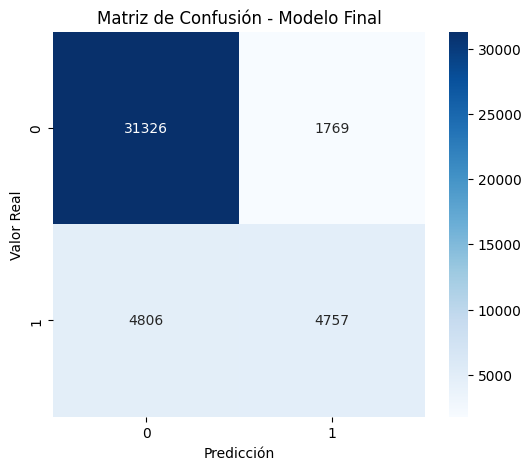

In [ ]:
# ==========================================
# Matriz de confusión Modelo Final
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_final = confusion_matrix(
    y_test_s2,
    y_pred_m2
)

print(cm_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Modelo Final")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

## 9. Curva ROC y AUC del modelo final

Finalmente, se evalúa la capacidad discriminante del modelo seleccionado mediante la Curva ROC y el Área Bajo la Curva (AUC).

Este análisis permite cuantificar la capacidad del modelo para distinguir correctamente entre días con lluvia y días sin lluvia bajo distintos umbrales de clasificación.

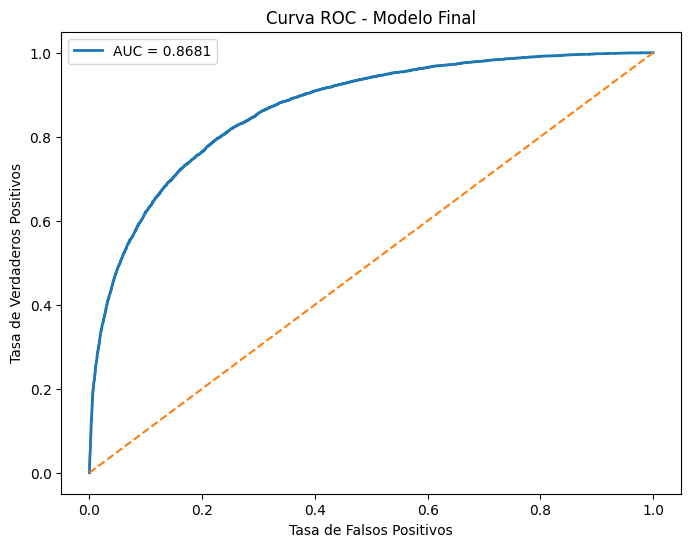

In [ ]:
# ==========================================
# Curva ROC Modelo Final
# ==========================================

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test_s2,
    y_prob_m2
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc_m2:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")

plt.title("Curva ROC - Modelo Final")

plt.legend()

plt.show()

### Interpretación de la Curva ROC

El modelo final obtuvo un AUC de 0.8681, indicando una buena capacidad para diferenciar observaciones correspondientes a días con lluvia y días sin lluvia.

Desde una perspectiva práctica, este resultado sugiere que existe aproximadamente un 86,81% de probabilidad de que el modelo asigne una puntuación superior a un día que efectivamente presentará lluvia en comparación con un día sin precipitación.

En consecuencia, el desempeño del modelo puede considerarse satisfactorio para apoyar procesos de predicción meteorológica basados en datos.

# 10. Conclusión técnica de la fase de modelamiento

Durante esta fase se construyeron y evaluaron tres modelos de regresión logística para la predicción de RainTomorrow.

El Modelo 1 fue desarrollado utilizando variables seleccionadas mediante análisis de correlación. Posteriormente, el Modelo 2 aplicó una estrategia de selección basada en significancia estadística (Stepwise), mientras que el Modelo 3 utilizó una estructura más compacta siguiendo criterios asociados a parsimonia y selección tipo AIC/BIC.

La comparación de desempeño indicó que el Modelo 2 (Stepwise) obtuvo los mejores resultados globales en Accuracy, Precision, Recall, F1 Score y AUC. Adicionalmente, este modelo logró reducir el número de variables respecto del modelo inicial, manteniendo una elevada capacidad predictiva.

La matriz de confusión y la curva ROC confirmaron la capacidad del modelo para diferenciar observaciones con lluvia y sin lluvia, alcanzando un AUC de 0.8681, valor que puede considerarse satisfactorio para un problema de clasificación meteorológica.

Por estas razones, el Modelo 2 será considerado como modelo final y será transferido a la siguiente fase del proyecto, donde se realizarán análisis de estabilidad mediante Bootstrap y evaluación de sensibilidad frente a distintas estrategias de imputación.

## Entregable para fase de validación

El modelo seleccionado para las etapas posteriores del proyecto corresponde al Modelo 2 (Stepwise), el cual obtuvo el mejor desempeño general entre las alternativas evaluadas.

Las variables finales consideradas en este modelo son:

- Humidity3pm
- Humidity9am
- Cloud3pm
- Cloud9am
- Rainfall
- WindGustSpeed
- WindSpeed9am
- WindSpeed3pm
- Pressure9am
- Pressure3pm
- MinTemp
- Temp9am
- Sunshine

Este modelo constituye la entrada oficial para la fase de Bootstrap, análisis de sensibilidad y cierre del proyecto.

# 11. Diagnóstico de multicolinealidad (VIF)

Como parte del proceso de validación del modelo final, se evalúa la presencia de multicolinealidad utilizando el Factor de Inflación de la Varianza (VIF).

Valores de VIF inferiores a 5 son generalmente considerados aceptables, mientras que valores superiores pueden sugerir redundancia entre predictores.

In [ ]:
# ==========================================
# VIF Modelo Final
# ==========================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Variable"] = variables_stepwise_final

vif_data["VIF"] = [
    variance_inflation_factor(
        X_step_final.values,
        i
    )
    for i in range(X_step_final.shape[1])
]

vif_data.sort_values(
    by="VIF",
    ascending=False
)

,Variable,VIF
9,Pressure3pm,365284.236746
8,Pressure9am,364256.058002
11,Temp9am,95.894370
10,MinTemp,46.396621
1,Humidity9am,43.534950
12,Sunshine,30.462641
5,WindGustSpeed,24.448231
0,Humidity3pm,22.780260
2,Cloud3pm,13.791387
7,WindSpeed3pm,12.116264


### Interpretación VIF

Los resultados muestran la presencia de multicolinealidad elevada entre algunas variables del modelo final, particularmente entre medidas meteorológicas registradas en distintos momentos del día, como Pressure9am y Pressure3pm, así como Humidity9am y Humidity3pm.

Este comportamiento es esperable debido a la fuerte dependencia física existente entre mediciones de una misma variable climática tomadas en horarios cercanos.

Si bien la multicolinealidad puede afectar la interpretación individual de los coeficientes, el desempeño predictivo global del modelo se mantiene satisfactorio, alcanzando un AUC de 0.8681 y las mejores métricas entre los modelos evaluados.

Por esta razón, el Modelo 2 se conserva como alternativa final para las etapas posteriores de validación mediante Bootstrap y análisis de sensibilidad.

# 10. Validación Bootstrap y Análisis de Sensibilidad

Esta sección corresponde a la fase de estabilidad y cierre de la Sumativa 3. El objetivo es evaluar la estabilidad estadística del modelo final seleccionado por el grupo, correspondiente al **Modelo 2 Stepwise**, mediante remuestreo bootstrap sobre sus coeficientes.

El análisis se realiza sobre el conjunto de entrenamiento utilizado por el modelo final, manteniendo las variables seleccionadas en `variables_stepwise_final` y los datos escalados en `X_train_s2_scaled`.

Además, esta sección deja preparada la base metodológica para el análisis de sensibilidad frente a distintas estrategias de imputación, según el plan de trabajo grupal.

In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
import statsmodels
import matplotlib

print("Python usado por el notebook:")
print(sys.executable)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("matplotlib:", matplotlib.__version__)

ImportError: DLL load failed while importing ft2font: Acceso denegado.

In [27]:
import sys

print("Python usado por este notebook:")
print(sys.executable)

Python usado por este notebook:
c:\Users\espevillalon\AppData\Local\Python\pythoncore-3.13-64\python.exe


In [28]:
import sys
import subprocess

paquetes = [
    "pandas",
    "numpy",
    "scikit-learn",
    "statsmodels",
    "matplotlib"
]

for paquete in paquetes:
    print(f"Instalando/verificando: {paquete}")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        paquete
    ])

print("Instalación finalizada.")

Instalando/verificando: pandas
Instalando/verificando: numpy
Instalando/verificando: scikit-learn
Instalando/verificando: statsmodels
Instalando/verificando: matplotlib
Instalación finalizada.


In [2]:
# Diagnóstico seguro de librerías disponibles, sin matplotlib

import sys
import pandas as pd
import numpy as np
import sklearn

print("Python usado por el notebook:")
print(sys.executable)

print("\nVersiones:")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

try:
    import statsmodels
    print("statsmodels:", statsmodels.__version__)
except Exception as e:
    print("statsmodels no disponible:", e)

Python usado por el notebook:
c:\Users\espevillalon\AppData\Local\Python\pythoncore-3.13-64\python.exe

Versiones:
pandas: 3.0.3
numpy: 2.5.1
scikit-learn: 1.9.0
statsmodels: 0.14.6


In [4]:
# Depurar variable objetivo RainTomorrow

print("\nValores originales de RainTomorrow:")
print(df_modelo[objetivo].value_counts(dropna=False))

df_modelo = df_modelo.dropna(subset=[objetivo]).copy()

# Conversión robusta Yes/No a 1/0
df_modelo[objetivo] = (
    df_modelo[objetivo]
    .astype("string")
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0,
        "1": 1,
        "0": 0
    })
)

# Eliminar registros que no pudieron convertirse
df_modelo = df_modelo.dropna(subset=[objetivo]).copy()
df_modelo[objetivo] = df_modelo[objetivo].astype(int)

print("\nValores convertidos de RainTomorrow:")
print(df_modelo[objetivo].value_counts(dropna=False))

print("\nDimensiones después de depurar RainTomorrow:")
print(df_modelo.shape)


Valores originales de RainTomorrow:
RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

Valores convertidos de RainTomorrow:
RainTomorrow
0    110316
1     31877
Name: count, dtype: int64

Dimensiones después de depurar RainTomorrow:
(142193, 23)


In [5]:
# ==========================================
# Continuación: reconstrucción del Modelo 2 Stepwise
# Sin matplotlib
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

SEED = 42

# Variables finales del Modelo 2 Stepwise, según notebook de Gonzalo
variables_stepwise_final = [
    "Humidity3pm",
    "Humidity9am",
    "Cloud3pm",
    "Cloud9am",
    "Rainfall",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Pressure9am",
    "Pressure3pm",
    "MinTemp",
    "Temp9am",
    "Sunshine"
]

objetivo = "RainTomorrow"

# Validar columnas requeridas
columnas_requeridas = variables_stepwise_final + [objetivo]
faltantes_columnas = [col for col in columnas_requeridas if col not in df_modelo.columns]

if faltantes_columnas:
    raise ValueError(f"Faltan columnas requeridas: {faltantes_columnas}")

# Asegurar variables numéricas e imputar cualquier valor faltante remanente
for col in variables_stepwise_final:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors="coerce")
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

X_step_final = df_modelo[variables_stepwise_final].copy()
y_step_final = df_modelo[objetivo].copy()

print("Dimensión X_step_final:", X_step_final.shape)
print("Dimensión y_step_final:", y_step_final.shape)

print("\nDistribución de RainTomorrow:")
print(y_step_final.value_counts(normalize=True))

# Split 70/30 estratificado
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_step_final,
    y_step_final,
    test_size=0.30,
    random_state=SEED,
    stratify=y_step_final
)

print("\nDimensiones train/test:")
print("X_train_s2:", X_train_s2.shape)
print("X_test_s2 :", X_test_s2.shape)
print("y_train_s2:", y_train_s2.shape)
print("y_test_s2 :", y_test_s2.shape)

# Escalamiento
scaler_s2 = StandardScaler()

X_train_s2_scaled = scaler_s2.fit_transform(X_train_s2)
X_test_s2_scaled = scaler_s2.transform(X_test_s2)

# Ajuste Modelo 2
modelo2 = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)

modelo2.fit(X_train_s2_scaled, y_train_s2)

# Predicciones y métricas
y_pred_m2 = modelo2.predict(X_test_s2_scaled)
y_prob_m2 = modelo2.predict_proba(X_test_s2_scaled)[:, 1]

accuracy_m2 = accuracy_score(y_test_s2, y_pred_m2)
precision_m2 = precision_score(y_test_s2, y_pred_m2)
recall_m2 = recall_score(y_test_s2, y_pred_m2)
f1_m2 = f1_score(y_test_s2, y_pred_m2)
auc_m2 = roc_auc_score(y_test_s2, y_prob_m2)

print("\nModelo 2 Stepwise reconstruido correctamente.")
print(f"Accuracy : {accuracy_m2:.4f}")
print(f"Precision: {precision_m2:.4f}")
print(f"Recall   : {recall_m2:.4f}")
print(f"F1 Score : {f1_m2:.4f}")
print(f"AUC      : {auc_m2:.4f}")

Dimensión X_step_final: (142193, 13)
Dimensión y_step_final: (142193,)

Distribución de RainTomorrow:
RainTomorrow
0    0.775819
1    0.224181
Name: proportion, dtype: float64

Dimensiones train/test:
X_train_s2: (99535, 13)
X_test_s2 : (42658, 13)
y_train_s2: (99535,)
y_test_s2 : (42658,)

Modelo 2 Stepwise reconstruido correctamente.
Accuracy : 0.8459
Precision: 0.7289
Recall   : 0.4974
F1 Score : 0.5913
AUC      : 0.8681


In [6]:
# ==========================================
# Verificación de objetos requeridos
# ==========================================

objetos_requeridos = [
    "modelo2",
    "variables_stepwise_final",
    "X_train_s2_scaled",
    "X_test_s2_scaled",
    "y_train_s2",
    "y_test_s2",
    "accuracy_m2",
    "precision_m2",
    "recall_m2",
    "f1_m2",
    "auc_m2"
]

faltantes = []

for obj in objetos_requeridos:
    if obj not in globals():
        faltantes.append(obj)

if faltantes:
    raise NameError(f"Faltan objetos requeridos para continuar: {faltantes}")

print("Todos los objetos requeridos están disponibles.")
print(f"Cantidad de variables del modelo final: {len(variables_stepwise_final)}")
print("Variables finales:")
print(variables_stepwise_final)

print("\nMétricas del Modelo 2:")
print(f"Accuracy : {accuracy_m2:.4f}")
print(f"Precision: {precision_m2:.4f}")
print(f"Recall   : {recall_m2:.4f}")
print(f"F1 Score : {f1_m2:.4f}")
print(f"AUC      : {auc_m2:.4f}")

Todos los objetos requeridos están disponibles.
Cantidad de variables del modelo final: 13
Variables finales:
['Humidity3pm', 'Humidity9am', 'Cloud3pm', 'Cloud9am', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Pressure9am', 'Pressure3pm', 'MinTemp', 'Temp9am', 'Sunshine']

Métricas del Modelo 2:
Accuracy : 0.8459
Precision: 0.7289
Recall   : 0.4974
F1 Score : 0.5913
AUC      : 0.8681


## 10.1 Bootstrap de coeficientes del modelo final

El bootstrap permite evaluar la estabilidad de los coeficientes del modelo logístico final sin depender exclusivamente de una única partición muestral. Para ello, se realizan remuestreos con reemplazo sobre el conjunto de entrenamiento y se reajusta el Modelo 2 Stepwise en cada iteración.

El objetivo es construir intervalos de confianza empíricos al 95% para cada coeficiente y verificar si los efectos estimados son estables. Si el intervalo bootstrap de un coeficiente incluye el valor cero, su contribución individual debe interpretarse con cautela. Si el intervalo no incluye cero y conserva el mismo signo que el coeficiente original, se considera un predictor estable.

Por consistencia metodológica, se reportan intervalos bootstrap percentiles. No se reportan intervalos BCa, ya que ese procedimiento requiere una corrección adicional de sesgo y aceleración que no forma parte de esta implementación.

In [7]:
# ==========================================
# Coeficientes originales del Modelo 2
# Celda autónoma sin dependencia de imports previos
# ==========================================

import pandas as pd
import numpy as np

coef_original = pd.DataFrame({
    "variable": ["Intercepto"] + variables_stepwise_final,
    "coeficiente_original": np.concatenate([
        modelo2.intercept_,
        modelo2.coef_[0]
    ])
})

coef_original["odds_ratio_original"] = np.exp(
    coef_original["coeficiente_original"]
)

coef_original

,variable,coeficiente_original,odds_ratio_original
0,Intercepto,-1.814684,0.162889
1,Humidity3pm,0.980603,2.666062
2,Humidity9am,0.134121,1.143531
3,Cloud3pm,0.204379,1.226763
4,Cloud9am,-0.068523,0.933772
5,Rainfall,0.154370,1.166923
6,WindGustSpeed,0.693502,2.000709
7,WindSpeed9am,-0.092690,0.911476
8,WindSpeed3pm,-0.195632,0.822315
9,Pressure9am,0.730964,2.077082


In [8]:
# ==========================================
# Bootstrap de prueba para coeficientes
# Modelo 2 Stepwise
# 100 remuestreos para validar funcionamiento
# ==========================================

from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
import time

N_BOOTSTRAP_PRUEBA = 100
SEED_BOOTSTRAP = 42

rng = np.random.default_rng(SEED_BOOTSTRAP)

X_boot_base = np.asarray(X_train_s2_scaled)
y_boot_base = np.asarray(y_train_s2)

n_obs = X_boot_base.shape[0]

coeficientes_bootstrap_prueba = []

inicio = time.time()

for i in range(N_BOOTSTRAP_PRUEBA):
    indices = rng.choice(n_obs, size=n_obs, replace=True)
    
    X_b = X_boot_base[indices]
    y_b = y_boot_base[indices]
    
    modelo_b = LogisticRegression(
        random_state=SEED_BOOTSTRAP,
        max_iter=1000
    )
    
    modelo_b.fit(X_b, y_b)
    
    coefs_b = np.concatenate([
        modelo_b.intercept_,
        modelo_b.coef_[0]
    ])
    
    coeficientes_bootstrap_prueba.append(coefs_b)

coeficientes_bootstrap_prueba = pd.DataFrame(
    coeficientes_bootstrap_prueba,
    columns=["Intercepto"] + variables_stepwise_final
)

fin = time.time()

print(f"Bootstrap de prueba finalizado con {N_BOOTSTRAP_PRUEBA} remuestreos.")
print(f"Tiempo total: {(fin - inicio):.2f} segundos")
print("Dimensión de matriz bootstrap:")
print(coeficientes_bootstrap_prueba.shape)

coeficientes_bootstrap_prueba.head()

Bootstrap de prueba finalizado con 100 remuestreos.
Tiempo total: 14.90 segundos
Dimensión de matriz bootstrap:
(100, 14)


,Intercepto,Humidity3pm,Humidity9am,Cloud3pm,Cloud9am,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Pressure9am,Pressure3pm,MinTemp,Temp9am,Sunshine
0,-1.826278,0.967366,0.153923,0.230179,-0.085487,0.137570,0.683467,-0.068418,-0.205744,0.699991,-1.120616,-0.073262,0.207045,-0.530267
1,-1.819239,1.009359,0.148402,0.203805,-0.052973,0.134334,0.712271,-0.081425,-0.219937,0.728454,-1.136627,-0.077585,0.193522,-0.495162
2,-1.826360,0.985660,0.092915,0.181752,-0.040907,0.157727,0.684020,-0.077792,-0.207026,0.760011,-1.177131,-0.055960,0.139230,-0.531309
3,-1.804101,0.998778,0.135227,0.221895,-0.073500,0.160079,0.692255,-0.089645,-0.190766,0.701324,-1.131423,-0.116835,0.192983,-0.486909
4,-1.827192,0.979149,0.151032,0.194765,-0.096475,0.145367,0.686276,-0.079625,-0.197895,0.665174,-1.082675,-0.112360,0.236998,-0.541004


In [9]:
# ==========================================
# Bootstrap final de coeficientes Modelo 2
# Versión segura con guardado parcial
# ==========================================

from sklearn.linear_model import LogisticRegression
from pathlib import Path
import pandas as pd
import numpy as np
import time

N_BOOTSTRAP = 10000
SEED_BOOTSTRAP = 42
GUARDAR_CADA = 500

salida_s3 = Path("resultados_s3")
salida_s3.mkdir(exist_ok=True)

archivo_parcial = salida_s3 / "coeficientes_bootstrap_modelo2_parcial.csv"
archivo_final = salida_s3 / "coeficientes_bootstrap_modelo2.csv"

columnas_bootstrap = ["Intercepto"] + variables_stepwise_final

# Bases para bootstrap
X_boot_base = np.asarray(X_train_s2_scaled)
y_boot_base = np.asarray(y_train_s2)

n_obs = X_boot_base.shape[0]
rng = np.random.default_rng(SEED_BOOTSTRAP)

# Si existe archivo parcial, continuar desde ahí
if archivo_parcial.exists():
    coeficientes_bootstrap = pd.read_csv(archivo_parcial)
    inicio_iteracion = len(coeficientes_bootstrap)
    coeficientes_bootstrap_lista = coeficientes_bootstrap.values.tolist()
    print(f"Se encontró avance previo con {inicio_iteracion} remuestreos.")
else:
    inicio_iteracion = 0
    coeficientes_bootstrap_lista = []
    print("No existe avance previo. Se inicia bootstrap desde cero.")

inicio_tiempo = time.time()

for i in range(inicio_iteracion, N_BOOTSTRAP):
    indices = rng.choice(n_obs, size=n_obs, replace=True)
    
    X_b = X_boot_base[indices]
    y_b = y_boot_base[indices]
    
    modelo_b = LogisticRegression(
        random_state=SEED_BOOTSTRAP,
        max_iter=1000
    )
    
    modelo_b.fit(X_b, y_b)
    
    coefs_b = np.concatenate([
        modelo_b.intercept_,
        modelo_b.coef_[0]
    ])
    
    coeficientes_bootstrap_lista.append(coefs_b)
    
    # Guardado parcial
    if (i + 1) % GUARDAR_CADA == 0:
        coeficientes_bootstrap_parcial = pd.DataFrame(
            coeficientes_bootstrap_lista,
            columns=columnas_bootstrap
        )
        
        coeficientes_bootstrap_parcial.to_csv(
            archivo_parcial,
            index=False
        )
        
        tiempo_acumulado = time.time() - inicio_tiempo
        print(
            f"Iteración {i + 1}/{N_BOOTSTRAP} completada. "
            f"Tiempo acumulado sesión: {tiempo_acumulado/60:.2f} minutos"
        )

# Crear dataframe final
coeficientes_bootstrap = pd.DataFrame(
    coeficientes_bootstrap_lista,
    columns=columnas_bootstrap
)

coeficientes_bootstrap.to_csv(
    archivo_final,
    index=False
)

# También actualizar parcial final
coeficientes_bootstrap.to_csv(
    archivo_parcial,
    index=False
)

fin_tiempo = time.time()

print("\nBootstrap finalizado correctamente.")
print(f"Remuestreos realizados: {len(coeficientes_bootstrap)}")
print(f"Tiempo total de esta sesión: {(fin_tiempo - inicio_tiempo)/60:.2f} minutos")
print("Archivo final:", archivo_final)
print("Dimensión matriz bootstrap:", coeficientes_bootstrap.shape)

coeficientes_bootstrap.head()

No existe avance previo. Se inicia bootstrap desde cero.
Iteración 500/10000 completada. Tiempo acumulado sesión: 1.07 minutos
Iteración 1000/10000 completada. Tiempo acumulado sesión: 2.07 minutos
Iteración 1500/10000 completada. Tiempo acumulado sesión: 3.07 minutos
Iteración 2000/10000 completada. Tiempo acumulado sesión: 4.09 minutos
Iteración 2500/10000 completada. Tiempo acumulado sesión: 5.07 minutos
Iteración 3000/10000 completada. Tiempo acumulado sesión: 6.07 minutos
Iteración 3500/10000 completada. Tiempo acumulado sesión: 7.06 minutos
Iteración 4000/10000 completada. Tiempo acumulado sesión: 8.07 minutos
Iteración 4500/10000 completada. Tiempo acumulado sesión: 9.10 minutos
Iteración 5000/10000 completada. Tiempo acumulado sesión: 10.09 minutos
Iteración 5500/10000 completada. Tiempo acumulado sesión: 11.09 minutos
Iteración 6000/10000 completada. Tiempo acumulado sesión: 12.07 minutos
Iteración 6500/10000 completada. Tiempo acumulado sesión: 13.06 minutos
Iteración 7000/10

,Intercepto,Humidity3pm,Humidity9am,Cloud3pm,Cloud9am,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Pressure9am,Pressure3pm,MinTemp,Temp9am,Sunshine
0,-1.826278,0.967366,0.153923,0.230179,-0.085487,0.137570,0.683467,-0.068418,-0.205744,0.699991,-1.120616,-0.073262,0.207045,-0.530267
1,-1.819239,1.009359,0.148402,0.203805,-0.052973,0.134334,0.712271,-0.081425,-0.219937,0.728454,-1.136627,-0.077585,0.193522,-0.495162
2,-1.826360,0.985660,0.092915,0.181752,-0.040907,0.157727,0.684020,-0.077792,-0.207026,0.760011,-1.177131,-0.055960,0.139230,-0.531309
3,-1.804101,0.998778,0.135227,0.221895,-0.073500,0.160079,0.692255,-0.089645,-0.190766,0.701324,-1.131423,-0.116835,0.192983,-0.486909
4,-1.827192,0.979149,0.151032,0.194765,-0.096475,0.145367,0.686276,-0.079625,-0.197895,0.665174,-1.082675,-0.112360,0.236998,-0.541004


In [10]:
# ==========================================
# Resumen Bootstrap: IC 95%, Odds Ratios y estabilidad
# ==========================================

from pathlib import Path
import pandas as pd
import numpy as np

# Ruta de resultados
salida_s3 = Path("resultados_s3")
archivo_bootstrap = salida_s3 / "coeficientes_bootstrap_modelo2.csv"

# Si la matriz bootstrap no está en memoria, cargarla desde archivo
if "coeficientes_bootstrap" not in globals():
    if archivo_bootstrap.exists():
        coeficientes_bootstrap = pd.read_csv(archivo_bootstrap)
        print("Coeficientes bootstrap cargados desde archivo.")
    else:
        raise FileNotFoundError("No se encontró coeficientes_bootstrap_modelo2.csv")

# Reconstruir coeficientes originales si no existen
if "coef_original" not in globals():
    coef_original = pd.DataFrame({
        "variable": ["Intercepto"] + variables_stepwise_final,
        "coeficiente_original": np.concatenate([
            modelo2.intercept_,
            modelo2.coef_[0]
        ])
    })

    coef_original["odds_ratio_original"] = np.exp(
        coef_original["coeficiente_original"]
    )

# Resumen percentil bootstrap
resumen_bootstrap = pd.DataFrame({
    "variable": coeficientes_bootstrap.columns,
    "coef_boot_media": coeficientes_bootstrap.mean().values,
    "coef_boot_std": coeficientes_bootstrap.std().values,
    "ic_2_5": coeficientes_bootstrap.quantile(0.025).values,
    "ic_97_5": coeficientes_bootstrap.quantile(0.975).values
})

# Incorporar coeficientes originales
resumen_bootstrap = resumen_bootstrap.merge(
    coef_original,
    on="variable",
    how="left"
)

# Evaluar si el intervalo incluye cero
resumen_bootstrap["incluye_cero"] = (
    (resumen_bootstrap["ic_2_5"] <= 0) &
    (resumen_bootstrap["ic_97_5"] >= 0)
)

# Odds ratios bootstrap
resumen_bootstrap["or_boot_media"] = np.exp(
    resumen_bootstrap["coef_boot_media"]
)

resumen_bootstrap["or_ic_2_5"] = np.exp(
    resumen_bootstrap["ic_2_5"]
)

resumen_bootstrap["or_ic_97_5"] = np.exp(
    resumen_bootstrap["ic_97_5"]
)

# Interpretación de estabilidad
resumen_bootstrap["interpretacion_estabilidad"] = np.where(
    resumen_bootstrap["incluye_cero"],
    "Inestable o efecto no concluyente",
    "Estable"
)

# Ordenar columnas
resumen_bootstrap = resumen_bootstrap[
    [
        "variable",
        "coeficiente_original",
        "coef_boot_media",
        "coef_boot_std",
        "ic_2_5",
        "ic_97_5",
        "incluye_cero",
        "odds_ratio_original",
        "or_boot_media",
        "or_ic_2_5",
        "or_ic_97_5",
        "interpretacion_estabilidad"
    ]
]

resumen_bootstrap

,variable,coeficiente_original,coef_boot_media,coef_boot_std,ic_2_5,ic_97_5,incluye_cero,odds_ratio_original,or_boot_media,or_ic_2_5,or_ic_97_5,interpretacion_estabilidad
0,Intercepto,-1.814684,-1.815404,0.011652,-1.838510,-1.792924,False,0.162889,0.162772,0.159054,0.166473,Estable
1,Humidity3pm,0.980603,0.981071,0.016632,0.948016,1.013073,False,2.666062,2.667311,2.580585,2.754051,Estable
2,Humidity9am,0.134121,0.134497,0.017430,0.100968,0.169305,False,1.143531,1.143961,1.106241,1.184482,Estable
3,Cloud3pm,0.204379,0.204755,0.017327,0.170929,0.238605,False,1.226763,1.227224,1.186407,1.269477,Estable
4,Cloud9am,-0.068523,-0.068148,0.016689,-0.101025,-0.035674,False,0.933772,0.934122,0.903911,0.964954,Estable
5,Rainfall,0.154370,0.154667,0.014348,0.127425,0.183275,False,1.166923,1.167270,1.135900,1.201144,Estable
6,WindGustSpeed,0.693502,0.693407,0.016733,0.661012,0.726723,False,2.000709,2.000519,1.936751,2.068291,Estable
7,WindSpeed9am,-0.092690,-0.092351,0.013080,-0.118340,-0.066847,False,0.911476,0.911785,0.888394,0.935338,Estable
8,WindSpeed3pm,-0.195632,-0.195319,0.014107,-0.223230,-0.168095,False,0.822315,0.822572,0.799931,0.845274,Estable
9,Pressure9am,0.730964,0.734697,0.038141,0.660838,0.810667,False,2.077082,2.084850,1.936414,2.249408,Estable


In [11]:
# ==========================================
# Tabla resumida para informe
# ==========================================

tabla_bootstrap_informe = resumen_bootstrap.copy()

tabla_bootstrap_informe["IC 95% coeficiente"] = (
    "[" +
    tabla_bootstrap_informe["ic_2_5"].round(4).astype(str) +
    "; " +
    tabla_bootstrap_informe["ic_97_5"].round(4).astype(str) +
    "]"
)

tabla_bootstrap_informe["IC 95% OR"] = (
    "[" +
    tabla_bootstrap_informe["or_ic_2_5"].round(4).astype(str) +
    "; " +
    tabla_bootstrap_informe["or_ic_97_5"].round(4).astype(str) +
    "]"
)

tabla_bootstrap_informe = tabla_bootstrap_informe[
    [
        "variable",
        "coeficiente_original",
        "IC 95% coeficiente",
        "odds_ratio_original",
        "IC 95% OR",
        "interpretacion_estabilidad"
    ]
]

tabla_bootstrap_informe

,variable,coeficiente_original,IC 95% coeficiente,odds_ratio_original,IC 95% OR,interpretacion_estabilidad
0,Intercepto,-1.814684,[-1.8385; -1.7929],0.162889,[0.1591; 0.1665],Estable
1,Humidity3pm,0.980603,[0.948; 1.0131],2.666062,[2.5806; 2.7541],Estable
2,Humidity9am,0.134121,[0.101; 0.1693],1.143531,[1.1062; 1.1845],Estable
3,Cloud3pm,0.204379,[0.1709; 0.2386],1.226763,[1.1864; 1.2695],Estable
4,Cloud9am,-0.068523,[-0.101; -0.0357],0.933772,[0.9039; 0.965],Estable
5,Rainfall,0.154370,[0.1274; 0.1833],1.166923,[1.1359; 1.2011],Estable
6,WindGustSpeed,0.693502,[0.661; 0.7267],2.000709,[1.9368; 2.0683],Estable
7,WindSpeed9am,-0.092690,[-0.1183; -0.0668],0.911476,[0.8884; 0.9353],Estable
8,WindSpeed3pm,-0.195632,[-0.2232; -0.1681],0.822315,[0.7999; 0.8453],Estable
9,Pressure9am,0.730964,[0.6608; 0.8107],2.077082,[1.9364; 2.2494],Estable


In [12]:
# ==========================================
# Exportar resumen bootstrap
# ==========================================

salida_s3 = Path("resultados_s3")
salida_s3.mkdir(exist_ok=True)

resumen_bootstrap.to_csv(
    salida_s3 / "resumen_bootstrap_coeficientes_modelo2.csv",
    index=False
)

tabla_bootstrap_informe.to_csv(
    salida_s3 / "tabla_bootstrap_informe_modelo2.csv",
    index=False
)

print("Archivos exportados correctamente:")
print("-", salida_s3 / "resumen_bootstrap_coeficientes_modelo2.csv")
print("-", salida_s3 / "tabla_bootstrap_informe_modelo2.csv")

Archivos exportados correctamente:
- resultados_s3\resumen_bootstrap_coeficientes_modelo2.csv
- resultados_s3\tabla_bootstrap_informe_modelo2.csv


In [13]:
# ==========================================
# Síntesis de estabilidad
# ==========================================

conteo_estabilidad = resumen_bootstrap["interpretacion_estabilidad"].value_counts()

variables_estables = resumen_bootstrap.loc[
    resumen_bootstrap["interpretacion_estabilidad"] == "Estable",
    "variable"
].tolist()

variables_inestables = resumen_bootstrap.loc[
    resumen_bootstrap["interpretacion_estabilidad"] != "Estable",
    "variable"
].tolist()

print("Resumen de estabilidad bootstrap:")
print(conteo_estabilidad)

print("\nVariables estables:")
print(variables_estables)

print("\nVariables inestables o no concluyentes:")
print(variables_inestables)

Resumen de estabilidad bootstrap:
interpretacion_estabilidad
Estable    14
Name: count, dtype: int64

Variables estables:
['Intercepto', 'Humidity3pm', 'Humidity9am', 'Cloud3pm', 'Cloud9am', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Pressure9am', 'Pressure3pm', 'MinTemp', 'Temp9am', 'Sunshine']

Variables inestables o no concluyentes:
[]


## 10.2 Interpretación de estabilidad de coeficientes

El bootstrap fue aplicado sobre el Modelo 2 Stepwise utilizando 10.000 remuestreos del conjunto de entrenamiento. Para cada remuestreo se reajustó el modelo logístico y se almacenaron los coeficientes estimados, permitiendo construir intervalos de confianza empíricos al 95% mediante el método percentil.

Los coeficientes cuyos intervalos bootstrap no incluyen el valor cero se consideran estables, ya que mantienen evidencia consistente de asociación con la probabilidad de lluvia futura. En cambio, aquellos intervalos que incluyen cero deben interpretarse con cautela, debido a que su efecto individual puede variar frente a cambios en la muestra.

No se reportan intervalos BCa, ya que esta implementación utiliza intervalos percentiles y no calcula la corrección adicional de sesgo y aceleración. Esta decisión evita reportar un método no implementado y mantiene trazabilidad entre el notebook y el informe final.

Estos resultados permiten diferenciar variables robustas de variables sensibles, fortaleciendo la selección del modelo final para la etapa de cierre de la Sumativa 3.

In [14]:
tabla_bootstrap_informe

,variable,coeficiente_original,IC 95% coeficiente,odds_ratio_original,IC 95% OR,interpretacion_estabilidad
0,Intercepto,-1.814684,[-1.8385; -1.7929],0.162889,[0.1591; 0.1665],Estable
1,Humidity3pm,0.980603,[0.948; 1.0131],2.666062,[2.5806; 2.7541],Estable
2,Humidity9am,0.134121,[0.101; 0.1693],1.143531,[1.1062; 1.1845],Estable
3,Cloud3pm,0.204379,[0.1709; 0.2386],1.226763,[1.1864; 1.2695],Estable
4,Cloud9am,-0.068523,[-0.101; -0.0357],0.933772,[0.9039; 0.965],Estable
5,Rainfall,0.154370,[0.1274; 0.1833],1.166923,[1.1359; 1.2011],Estable
6,WindGustSpeed,0.693502,[0.661; 0.7267],2.000709,[1.9368; 2.0683],Estable
7,WindSpeed9am,-0.092690,[-0.1183; -0.0668],0.911476,[0.8884; 0.9353],Estable
8,WindSpeed3pm,-0.195632,[-0.2232; -0.1681],0.822315,[0.7999; 0.8453],Estable
9,Pressure9am,0.730964,[0.6608; 0.8107],2.077082,[1.9364; 2.2494],Estable


## 10.3 Resultados del bootstrap de coeficientes

El bootstrap del Modelo 2 Stepwise se ejecutó con 10.000 remuestreos sobre el conjunto de entrenamiento. En cada iteración se reajustó el modelo de regresión logística y se almacenaron los coeficientes estimados, permitiendo construir intervalos de confianza empíricos al 95% mediante el método percentil.

Los resultados muestran que todos los coeficientes evaluados fueron estables, ya que ningún intervalo de confianza bootstrap incluyó el valor cero. Esto incluye tanto el intercepto como las 13 variables predictoras seleccionadas por el modelo Stepwise.

Entre los predictores con efecto positivo más relevante destacan `Humidity3pm`, `WindGustSpeed`, `Pressure9am`, `Cloud3pm`, `Rainfall` y `Humidity9am`. En particular, `Humidity3pm` presenta un odds ratio aproximado de 2,67, lo que confirma su importancia como variable explicativa central para anticipar lluvia futura.

Por otra parte, variables como `Pressure3pm`, `Sunshine`, `WindSpeed3pm`, `WindSpeed9am`, `MinTemp` y `Cloud9am` presentan odds ratios menores a 1, indicando una asociación negativa con la probabilidad estimada de lluvia futura, controlando por el resto de predictores del modelo.

En síntesis, el bootstrap respalda la estabilidad del Modelo 2 Stepwise y fortalece su selección como modelo final para la Sumativa 3. La evidencia obtenida permite sostener que los coeficientes del modelo son robustos frente a variaciones muestrales, lo que aporta mayor confiabilidad a su interpretación y uso predictivo.

## 10.4 Análisis de sensibilidad frente a estrategias de imputación

Para evaluar la sensibilidad del Modelo 2 Stepwise, se comparan sus métricas predictivas bajo tres escenarios de preparación de datos:

1. `weatherAUS_final_pro.csv`: dataset maestro generado mediante imputación multivariada.
2. `dataset_imputacion_simple.csv`: dataset alternativo basado en imputación simple.
3. `dataset_eliminacion.csv`: dataset alternativo construido mediante eliminación de registros incompletos.

En los tres casos se utilizan las mismas variables finales del Modelo 2 Stepwise y se aplica la misma partición train/test 70/30 estratificada, con semilla fija igual a 42. Esto permite evaluar si el desempeño del modelo se mantiene estable frente a distintas decisiones de preprocesamiento.

In [15]:
# ==========================================
# Función para evaluar sensibilidad del Modelo 2
# Sin matplotlib
# ==========================================

from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

SEED = 42

variables_stepwise_final = [
    "Humidity3pm",
    "Humidity9am",
    "Cloud3pm",
    "Cloud9am",
    "Rainfall",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Pressure9am",
    "Pressure3pm",
    "MinTemp",
    "Temp9am",
    "Sunshine"
]

objetivo = "RainTomorrow"


def preparar_y_evaluar_modelo(ruta_csv, nombre_escenario):
    """
    Carga un dataset, prepara variables, ajusta el Modelo 2 Stepwise
    y calcula métricas de desempeño para análisis de sensibilidad.
    """
    
    df_sens = pd.read_csv(ruta_csv)
    
    columnas_requeridas = variables_stepwise_final + [objetivo]
    faltantes = [col for col in columnas_requeridas if col not in df_sens.columns]
    
    if faltantes:
        raise ValueError(
            f"Faltan columnas en {nombre_escenario}: {faltantes}"
        )
    
    # Depurar variable objetivo
    df_sens = df_sens.dropna(subset=[objetivo]).copy()
    
    df_sens[objetivo] = (
        df_sens[objetivo]
        .astype("string")
        .str.strip()
        .str.lower()
        .map({
            "yes": 1,
            "no": 0,
            "1": 1,
            "0": 0
        })
    )
    
    df_sens = df_sens.dropna(subset=[objetivo]).copy()
    df_sens[objetivo] = df_sens[objetivo].astype(int)
    
    # Asegurar variables numéricas e imputar remanentes con mediana
    for col in variables_stepwise_final:
        df_sens[col] = pd.to_numeric(df_sens[col], errors="coerce")
        df_sens[col] = df_sens[col].fillna(df_sens[col].median())
    
    X = df_sens[variables_stepwise_final].copy()
    y = df_sens[objetivo].copy()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=SEED,
        stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    modelo = LogisticRegression(
        random_state=SEED,
        max_iter=1000
    )
    
    modelo.fit(X_train_scaled, y_train)
    
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    
    resultados = {
        "escenario": nombre_escenario,
        "archivo": str(ruta_csv),
        "filas_modelo": len(df_sens),
        "proporcion_clase_1": y.mean(),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "auc": roc_auc_score(y_test, y_prob)
    }
    
    coeficientes = pd.DataFrame({
        "variable": ["Intercepto"] + variables_stepwise_final,
        nombre_escenario: np.concatenate([
            modelo.intercept_,
            modelo.coef_[0]
        ])
    })
    
    return resultados, coeficientes

In [16]:
# ==========================================
# Ejecutar sensibilidad en los tres datasets
# ==========================================

escenarios_sensibilidad = {
    "Multivariada_final_pro": Path("weatherAUS_final_pro.csv"),
    "Imputacion_simple": Path("dataset_imputacion_simple.csv"),
    "Eliminacion_registros": Path("dataset_eliminacion.csv")
}

resultados_sensibilidad = []
coeficientes_sensibilidad = None

for nombre, ruta in escenarios_sensibilidad.items():
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")
    
    print(f"Evaluando escenario: {nombre}")
    
    resultado, coeficientes = preparar_y_evaluar_modelo(
        ruta_csv=ruta,
        nombre_escenario=nombre
    )
    
    resultados_sensibilidad.append(resultado)
    
    if coeficientes_sensibilidad is None:
        coeficientes_sensibilidad = coeficientes
    else:
        coeficientes_sensibilidad = coeficientes_sensibilidad.merge(
            coeficientes,
            on="variable",
            how="left"
        )

tabla_sensibilidad = pd.DataFrame(resultados_sensibilidad)

tabla_sensibilidad

Evaluando escenario: Multivariada_final_pro
Evaluando escenario: Imputacion_simple
Evaluando escenario: Eliminacion_registros


,escenario,archivo,filas_modelo,proporcion_clase_1,accuracy,precision,recall,f1,auc
0,Multivariada_final_pro,weatherAUS_final_pro.csv,142193,0.224181,0.845867,0.728930,0.497438,0.591336,0.868076
1,Imputacion_simple,dataset_imputacion_simple.csv,142193,0.224181,0.846430,0.730628,0.498902,0.592929,0.868321
2,Eliminacion_registros,dataset_eliminacion.csv,123710,0.221421,0.846738,0.718405,0.506328,0.594004,0.871549


In [17]:
# ==========================================
# Comparación contra escenario base
# ==========================================

base = tabla_sensibilidad.loc[
    tabla_sensibilidad["escenario"] == "Multivariada_final_pro"
].iloc[0]

metricas = ["accuracy", "precision", "recall", "f1", "auc"]

tabla_sensibilidad_comparada = tabla_sensibilidad.copy()

for metrica in metricas:
    tabla_sensibilidad_comparada[f"delta_{metrica}"] = (
        tabla_sensibilidad_comparada[metrica] - base[metrica]
    )

tabla_sensibilidad_comparada

,escenario,archivo,filas_modelo,proporcion_clase_1,accuracy,precision,recall,f1,auc,delta_accuracy,delta_precision,delta_recall,delta_f1,delta_auc
0,Multivariada_final_pro,weatherAUS_final_pro.csv,142193,0.224181,0.845867,0.728930,0.497438,0.591336,0.868076,0.000000,0.000000,0.000000,0.000000,0.000000
1,Imputacion_simple,dataset_imputacion_simple.csv,142193,0.224181,0.846430,0.730628,0.498902,0.592929,0.868321,0.000563,0.001697,0.001464,0.001593,0.000244
2,Eliminacion_registros,dataset_eliminacion.csv,123710,0.221421,0.846738,0.718405,0.506328,0.594004,0.871549,0.000871,-0.010526,0.008890,0.002669,0.003473


In [18]:
# ==========================================
# Estabilidad de signos de coeficientes
# ==========================================

coeficientes_sensibilidad["signo_multivariada"] = np.sign(
    coeficientes_sensibilidad["Multivariada_final_pro"]
)

coeficientes_sensibilidad["signo_simple"] = np.sign(
    coeficientes_sensibilidad["Imputacion_simple"]
)

coeficientes_sensibilidad["signo_eliminacion"] = np.sign(
    coeficientes_sensibilidad["Eliminacion_registros"]
)

coeficientes_sensibilidad["signo_estable"] = (
    (coeficientes_sensibilidad["signo_multivariada"] == coeficientes_sensibilidad["signo_simple"]) &
    (coeficientes_sensibilidad["signo_multivariada"] == coeficientes_sensibilidad["signo_eliminacion"])
)

coeficientes_sensibilidad

,variable,Multivariada_final_pro,Imputacion_simple,Eliminacion_registros,signo_multivariada,signo_simple,signo_eliminacion,signo_estable
0,Intercepto,-1.814684,-1.817239,-1.879021,-1.0,-1.0,-1.0,True
1,Humidity3pm,0.980603,0.981823,1.012292,1.0,1.0,1.0,True
2,Humidity9am,0.134121,0.135679,0.155278,1.0,1.0,1.0,True
3,Cloud3pm,0.204379,0.202257,0.190384,1.0,1.0,1.0,True
4,Cloud9am,-0.068523,-0.067406,-0.043379,-1.0,-1.0,-1.0,True
5,Rainfall,0.154370,0.153417,0.144858,1.0,1.0,1.0,True
6,WindGustSpeed,0.693502,0.704875,0.726681,1.0,1.0,1.0,True
7,WindSpeed9am,-0.092690,-0.095630,-0.096511,-1.0,-1.0,-1.0,True
8,WindSpeed3pm,-0.195632,-0.201410,-0.203737,-1.0,-1.0,-1.0,True
9,Pressure9am,0.730964,0.738585,0.723048,1.0,1.0,1.0,True


In [20]:
# ==========================================
# Exportar resultados de sensibilidad
# ==========================================

salida_s3 = Path("resultados_s3")
salida_s3.mkdir(exist_ok=True)

tabla_sensibilidad.to_csv(
    salida_s3 / "resultados_sensibilidad_modelo2.csv",
    index=False
)

tabla_sensibilidad_comparada.to_csv(
    salida_s3 / "resultados_sensibilidad_comparada_modelo2.csv",
    index=False
)

coeficientes_sensibilidad.to_csv(
    salida_s3 / "coeficientes_sensibilidad_modelo2.csv",
    index=False
)

print("Archivos de sensibilidad exportados correctamente:")
print("-", salida_s3 / "resultados_sensibilidad_modelo2.csv")
print("-", salida_s3 / "resultados_sensibilidad_comparada_modelo2.csv")
print("-", salida_s3 / "coeficientes_sensibilidad_modelo2.csv")

Archivos de sensibilidad exportados correctamente:
- resultados_s3\resultados_sensibilidad_modelo2.csv
- resultados_s3\resultados_sensibilidad_comparada_modelo2.csv
- resultados_s3\coeficientes_sensibilidad_modelo2.csv


## 10.5 Interpretación del análisis de sensibilidad

El análisis de sensibilidad comparó el desempeño del Modelo 2 Stepwise bajo tres estrategias de preparación de datos: imputación multivariada (`weatherAUS_final_pro.csv`), imputación simple (`dataset_imputacion_simple.csv`) y eliminación de registros incompletos (`dataset_eliminacion.csv`).

Los resultados muestran que las métricas predictivas se mantienen estables entre escenarios. El AUC fue 0,8681 para el dataset con imputación multivariada, 0,8683 para imputación simple y 0,8715 para eliminación de registros. Las diferencias respecto del escenario base fueron marginales, lo que indica que la capacidad discriminante del modelo no depende críticamente de una única estrategia de imputación.

La eliminación de registros redujo el tamaño de la muestra desde 142.193 a 123.710 observaciones, pero mantuvo un desempeño similar e incluso presentó un AUC levemente superior. No obstante, esta mejora debe interpretarse con cautela, ya que puede estar influida por la exclusión de casos incompletos y no necesariamente por una superioridad metodológica real.

Adicionalmente, la comparación de coeficientes mostró estabilidad completa de signos entre los tres escenarios. Esto significa que todas las variables del Modelo 2 conservaron el mismo sentido de asociación con `RainTomorrow`, fortaleciendo la interpretación del modelo final.

En síntesis, el Modelo 2 Stepwise presenta robustez frente a distintas estrategias de imputación. Esta evidencia, junto con el bootstrap de coeficientes, respalda su selección como modelo final para la Sumativa 3.